In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Taco_Sales.csv")
df.info

<bound method DataFrame.info of      Order ID   Restaurant Name     Location        Order Time  \
0      770487      El Taco Loco     New York  01-08-2024 14:55   
1      671858      El Taco Loco  San Antonio  23-11-2024 17:11   
2      688508        Taco Haven       Austin  21-11-2024 20:24   
3      944962  Spicy Taco House       Dallas  21-09-2024 06:43   
4      476417     Casa del Taco  San Antonio  24-07-2024 11:01   
..        ...               ...          ...               ...   
995    164891      La Vida Taco       Austin  27-05-2024 11:12   
996    232442    The Taco Stand  San Antonio  03-04-2025 20:51   
997    251729       Urban Tacos      Houston  23-01-2025 05:33   
998    940215       Taco Fiesta  San Antonio  05-09-2024 15:49   
999    326183      Grande Tacos      Phoenix  19-10-2024 14:21   

        Delivery Time  Delivery Duration (min) Taco Size     Taco Type  \
0    01-08-2024 15:36                       41   Regular  Chicken Taco   
1    23-11-2024 17:25      

In [3]:
df.head(3)

,Order ID,Restaurant Name,Location,Order Time,Delivery Time,Delivery Duration (min),Taco Size,Taco Type,Toppings Count,Distance (km),Price ($),Tip ($),Weekend Order
0,770487,El Taco Loco,New York,01-08-2024 14:55,01-08-2024 15:36,41,Regular,Chicken Taco,5,3.01,9.25,2.22,False
1,671858,El Taco Loco,San Antonio,23-11-2024 17:11,23-11-2024 17:25,14,Regular,Beef Taco,1,6.20,4.25,3.01,True
2,688508,Taco Haven,Austin,21-11-2024 20:24,21-11-2024 21:02,38,Large,Pork Taco,2,20.33,7.00,0.02,False


In [4]:
print(f"the number of null values is: \n{df.isnull().sum()}")


the number of null values is: 
Order ID                   0
Restaurant Name            0
Location                   0
Order Time                 0
Delivery Time              0
Delivery Duration (min)    0
Taco Size                  0
Taco Type                  0
Toppings Count             0
Distance (km)              0
Price ($)                  0
Tip ($)                    0
Weekend Order              0
dtype: int64


# EDA

C:\Users\rimsh\AppData\Local\Temp\ipykernel_18720\1162580690.py:76: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Month Name")
C:\Users\rimsh\AppData\Local\Temp\ipykernel_18720\1162580690.py:87: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Dow Name")


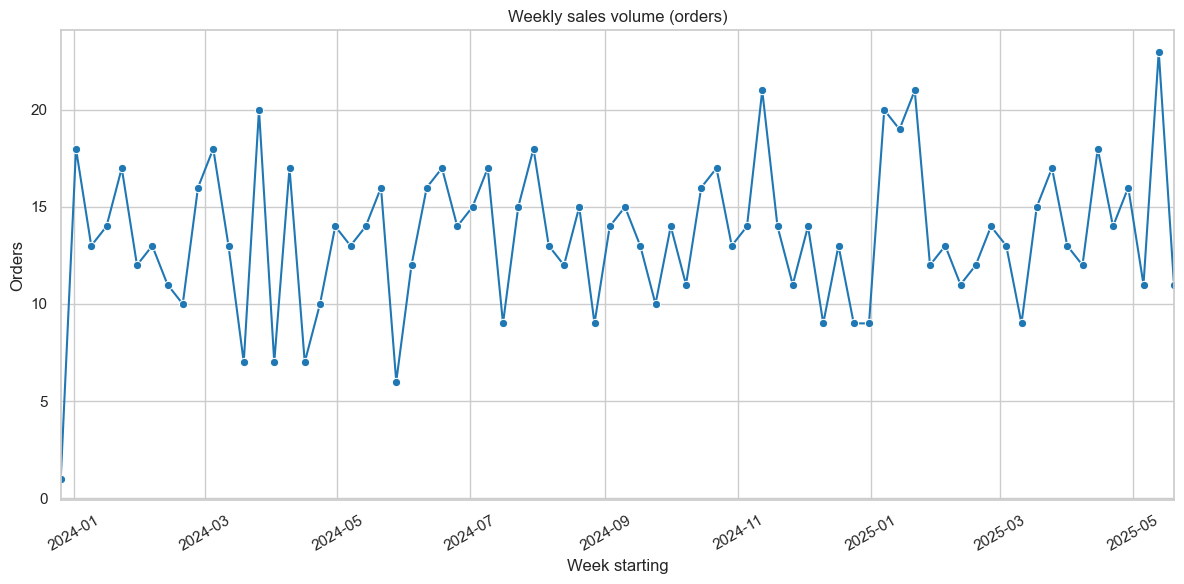

In [5]:
# --- Notebook setup ---
%matplotlib inline

# Aesthetics
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)



# --- Parse dates and engineer time features ---
# The file uses day-first format like "23-11-2024 17:11"
df["Order Time"] = pd.to_datetime(df["Order Time"], dayfirst=True, errors="coerce")
df["Delivery Time"] = pd.to_datetime(df["Delivery Time"], dayfirst=True, errors="coerce")

# Keep only rows with valid timestamps
df = df.dropna(subset=["Order Time", "Delivery Time"]).copy()

# Core time fields
df["Order Date"] = df["Order Time"].dt.floor("D")
df["Year"] = df["Order Time"].dt.year
df["Month"] = df["Order Time"].dt.month
df["Month Name"] = df["Order Time"].dt.month_name()
df["Week Start"] = df["Order Time"].dt.to_period("W-MON").apply(lambda p: p.start_time)
df["Dow Name"] = df["Order Time"].dt.day_name()
df["Hour"] = df["Order Time"].dt.hour

# Order Day-of-Week categorical order
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df["Dow Name"] = pd.Categorical(df["Dow Name"], categories=dow_order, ordered=True)

# Month categorical order (Jan -> Dec)
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]
df["Month Name"] = pd.Categorical(df["Month Name"], categories=month_order, ordered=True)

# --- Revenue and pricing metrics ---
# Revenue per order = base price + tip
df["Revenue"] = df["Price ($)"] + df["Tip ($)"]

# --- Daily/weekly aggregations ---
daily = (
    df.groupby("Order Date")
      .agg(orders=("Order ID", "count"),
           revenue=("Revenue", "sum"),
           avg_price=("Price ($)", "mean"),
           avg_revenue=("Revenue", "mean"))
      .reset_index()
      .sort_values("Order Date")
)

weekly = (
    df.groupby("Week Start")
      .agg(orders=("Order ID", "count"),
           revenue=("Revenue", "sum"),
           avg_price=("Price ($)", "mean"),
           avg_revenue=("Revenue", "mean"))
      .reset_index()
      .sort_values("Week Start")
)

# Month-year time series (for long-term seasonality trend lines)
month_year = (
    df.groupby([df["Order Time"].dt.to_period("M")])
      .agg(orders=("Order ID", "count"),
           revenue=("Revenue", "sum"),
           avg_price=("Price ($)", "mean"),
           avg_revenue=("Revenue", "mean"))
)
month_year.index = month_year.index.to_timestamp()
month_year = month_year.reset_index(names="Month Start").sort_values("Month Start")

# Month-of-year seasonal pattern (aggregated across years)
moy = (
    df.groupby("Month Name")
      .agg(orders=("Order ID", "count"),
           revenue=("Revenue", "sum"),
           avg_price=("Price ($)", "mean"),
           avg_revenue=("Revenue", "mean"))
      .reset_index()
      .sort_values("Month Name")
)

# Day-of-week pattern
dow = (
    df.groupby("Dow Name")
      .agg(orders=("Order ID", "count"),
           revenue=("Revenue", "sum"),
           avg_price=("Price ($)", "mean"),
           avg_revenue=("Revenue", "mean"))
      .reset_index()
      .sort_values("Dow Name")
)

# Weekend vs Weekday
if "Weekend Order" in df.columns:
    weekend = (
        df.groupby("Weekend Order")
          .agg(orders=("Order ID", "count"),
               revenue=("Revenue", "sum"),
               avg_price=("Price ($)", "mean"),
               avg_revenue=("Revenue", "mean"))
          .reset_index()
    )

# --- 1) Sales volume trend: weekly orders ---
fig, ax = plt.subplots()
sns.lineplot(data=weekly, x="Week Start", y="orders", marker="o", ax=ax, color="#1f77b4")
ax.set_title("Weekly sales volume (orders)")
ax.set_xlabel("Week starting")
ax.set_ylabel("Orders")
ax.margins(x=0)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()



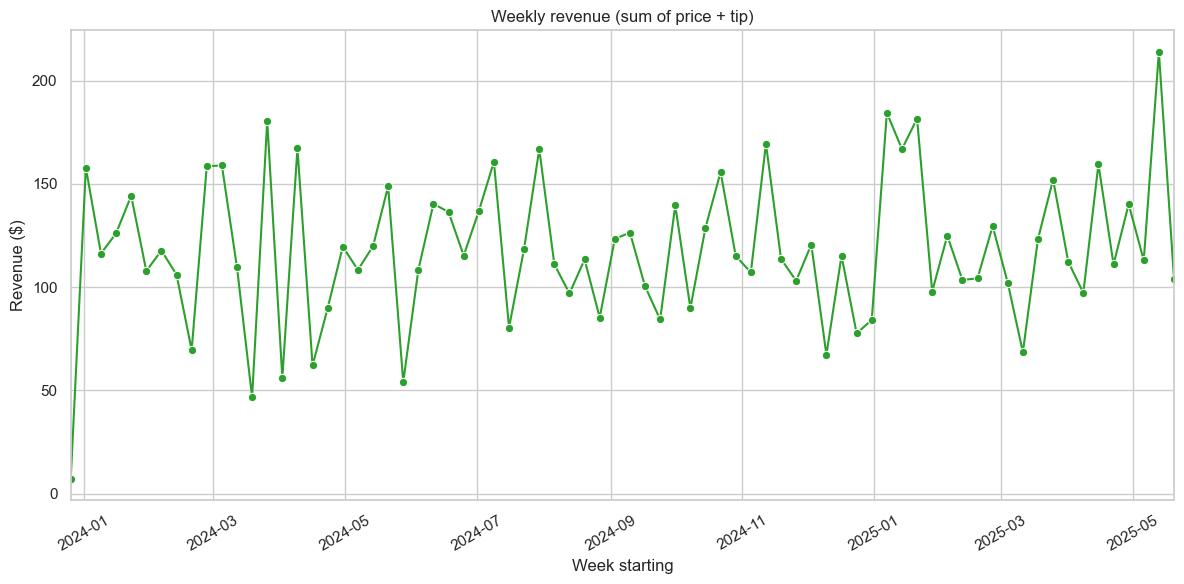

In [6]:
# --- 2) Revenue trend: weekly revenue ---
fig, ax = plt.subplots()
sns.lineplot(data=weekly, x="Week Start", y="revenue", marker="o", ax=ax, color="#2ca02c")
ax.set_title("Weekly revenue (sum of price + tip)")
ax.set_xlabel("Week starting")
ax.set_ylabel("Revenue ($)")
ax.margins(x=0)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

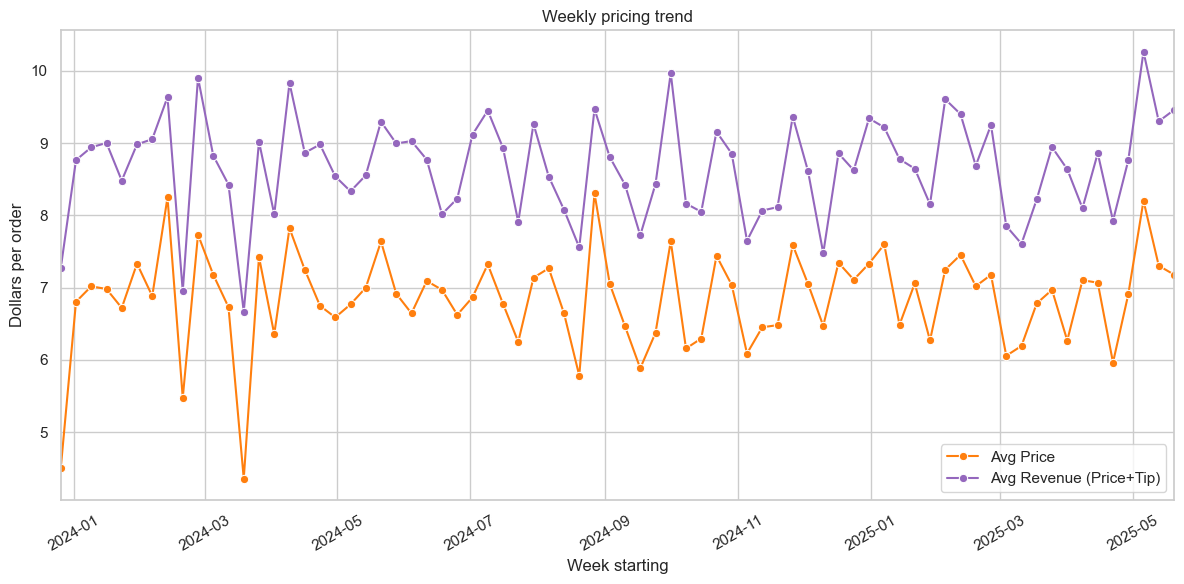

In [7]:
# --- 3) Pricing trend: average price vs average revenue per order (weekly) ---
fig, ax = plt.subplots()
sns.lineplot(data=weekly, x="Week Start", y="avg_price", marker="o", ax=ax, label="Avg Price", color="#ff7f0e")
sns.lineplot(data=weekly, x="Week Start", y="avg_revenue", marker="o", ax=ax, label="Avg Revenue (Price+Tip)", color="#9467bd")
ax.set_title("Weekly pricing trend")
ax.set_xlabel("Week starting")
ax.set_ylabel("Dollars per order")
ax.legend()
ax.margins(x=0)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

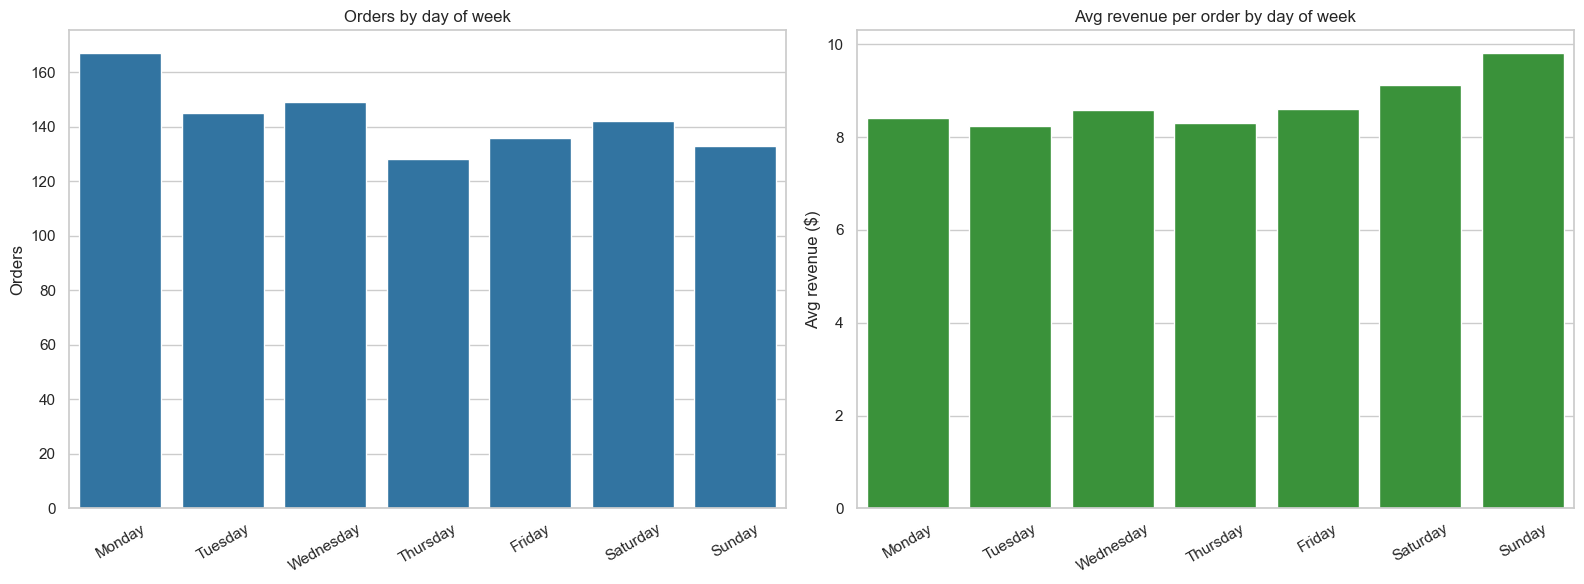

In [8]:
# --- 4) Day-of-week effects: orders and avg revenue ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=False)

sns.barplot(data=dow, x="Dow Name", y="orders", ax=axes[0], color="#1f77b4")
axes[0].set_title("Orders by day of week")
axes[0].set_xlabel("")
axes[0].set_ylabel("Orders")
for tick in axes[0].get_xticklabels(): tick.set_rotation(30)

sns.barplot(data=dow, x="Dow Name", y="avg_revenue", ax=axes[1], color="#2ca02c")
axes[1].set_title("Avg revenue per order by day of week")
axes[1].set_xlabel("")
axes[1].set_ylabel("Avg revenue ($)")
for tick in axes[1].get_xticklabels(): tick.set_rotation(30)

plt.tight_layout()
plt.show()

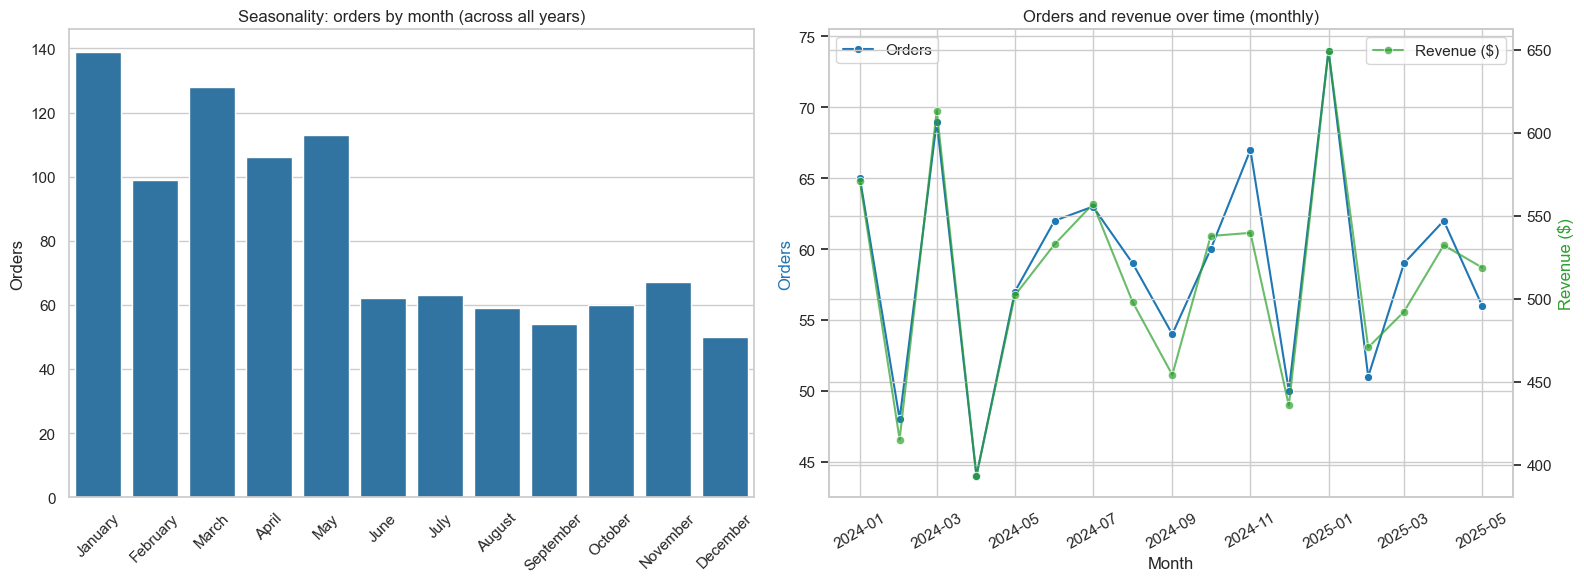

In [9]:
# --- 5) Seasonal effects: month-of-year and month-year ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=moy, x="Month Name", y="orders", ax=axes[0], color="#1f77b4")
axes[0].set_title("Seasonality: orders by month (across all years)")
axes[0].set_xlabel("")
axes[0].set_ylabel("Orders")
for tick in axes[0].get_xticklabels(): tick.set_rotation(45)

# Line plot for orders
sns.lineplot(
    data=month_year, 
    x="Month Start", 
    y="orders", 
    marker="o", 
    ax=axes[1], 
    label="Orders", 
    color="#1f77b4"
)

# Line plot for revenue on twin axis
ax2 = axes[1].twinx()
sns.lineplot(
    data=month_year, 
    x="Month Start", 
    y="revenue", 
    marker="o", 
    ax=ax2, 
    label="Revenue ($)", 
    color="#2ca02c", 
    alpha=0.7
)

# Titles and axis labels
axes[1].set_title("Orders and revenue over time (monthly)")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Orders", color="#1f77b4")
ax2.set_ylabel("Revenue ($)", color="#2ca02c")
axes[1].margins(x=0)

# Rotate x-ticks
for tick in axes[1].get_xticklabels(): tick.set_rotation(30)

# Add legends
axes[1].legend(loc="upper left")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

C:\Users\rimsh\AppData\Local\Temp\ipykernel_18720\125831644.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index="Dow Name", columns="Hour", values="Order ID", aggfunc="count", fill_value=0)


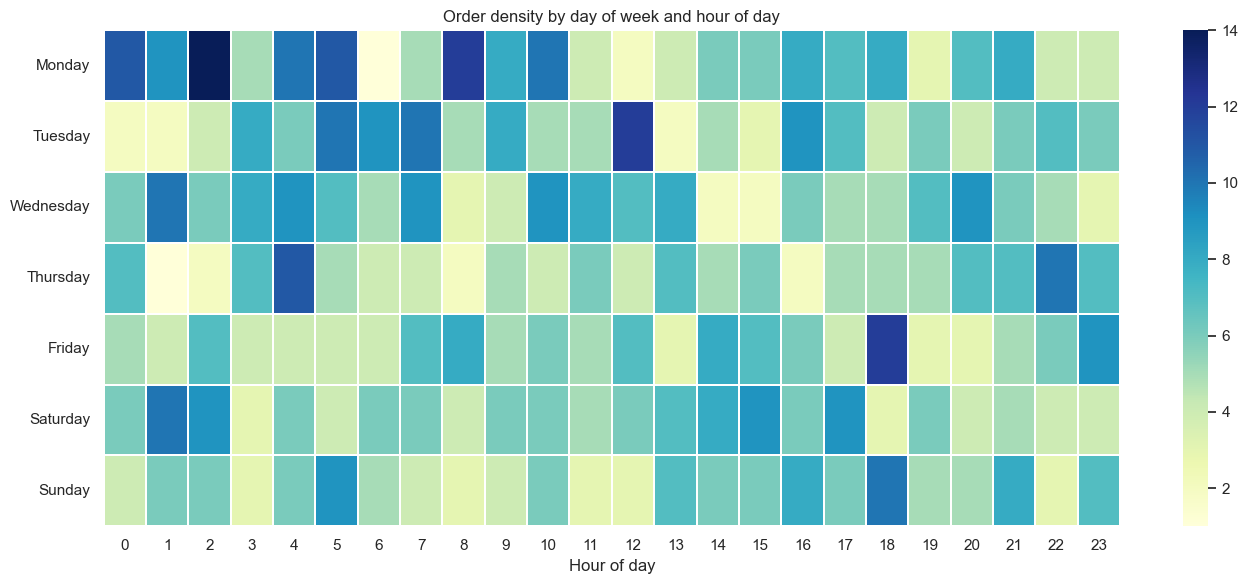

In [10]:
# --- 6) Hour-of-day x day-of-week heatmap (demand pattern) ---
heat = (
    df.pivot_table(index="Dow Name", columns="Hour", values="Order ID", aggfunc="count", fill_value=0)
      .reindex(dow_order)
)
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(heat, cmap="YlGnBu", linewidths=0.3, linecolor="white", ax=ax)
ax.set_title("Order density by day of week and hour of day")
ax.set_xlabel("Hour of day")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

C:\Users\rimsh\AppData\Local\Temp\ipykernel_18720\96343254.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weekend_labeled, x="Weekend Label", y="orders", ax=axes[0], palette=["#1f77b4", "#ff7f0e"])
C:\Users\rimsh\AppData\Local\Temp\ipykernel_18720\96343254.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weekend_labeled, x="Weekend Label", y="avg_revenue", ax=axes[1], palette=["#2ca02c", "#9467bd"])


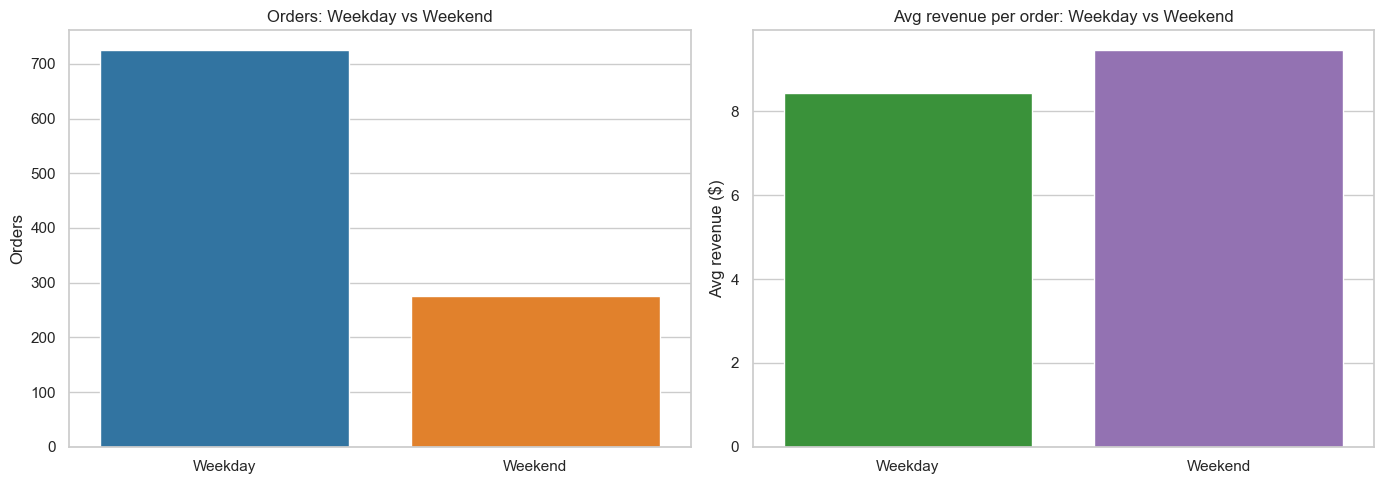

In [11]:
# --- 7) Weekend vs weekday comparison (if column exists) ---
if "Weekend Order" in df.columns:
    # Remap boolean to string labels
    df["Weekend Label"] = df["Weekend Order"].map({False: "Weekday", True: "Weekend"})

    weekend_labeled = (
        df.groupby("Weekend Label")
          .agg(orders=("Order ID", "count"),
               revenue=("Revenue", "sum"),
               avg_price=("Price ($)", "mean"),
               avg_revenue=("Revenue", "mean"))
          .reset_index()
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.barplot(data=weekend_labeled, x="Weekend Label", y="orders", ax=axes[0], palette=["#1f77b4", "#ff7f0e"])
    axes[0].set_title("Orders: Weekday vs Weekend")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("Orders")

    sns.barplot(data=weekend_labeled, x="Weekend Label", y="avg_revenue", ax=axes[1], palette=["#2ca02c", "#9467bd"])
    axes[1].set_title("Avg revenue per order: Weekday vs Weekend")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("Avg revenue ($)")

    plt.tight_layout()
    plt.show()

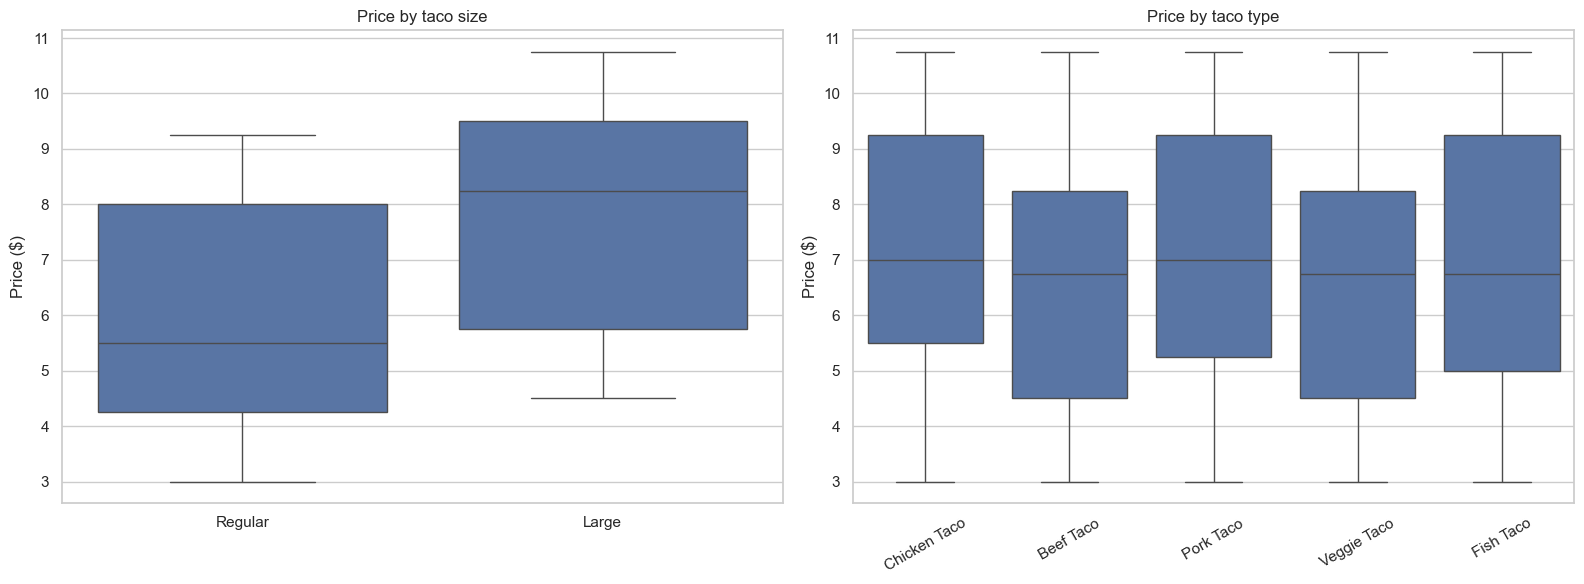

In [12]:
# --- 8) Optional: pricing by taco attributes (quick insights) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(data=df, x="Taco Size", y="Price ($)", ax=axes[0])
axes[0].set_title("Price by taco size")
axes[0].set_xlabel("")
axes[0].set_ylabel("Price ($)")

sns.boxplot(data=df, x="Taco Type", y="Price ($)", ax=axes[1])
axes[1].set_title("Price by taco type")
axes[1].set_xlabel("")
axes[1].set_ylabel("Price ($)")
for tick in axes[1].get_xticklabels(): tick.set_rotation(30)

plt.tight_layout()
plt.show()

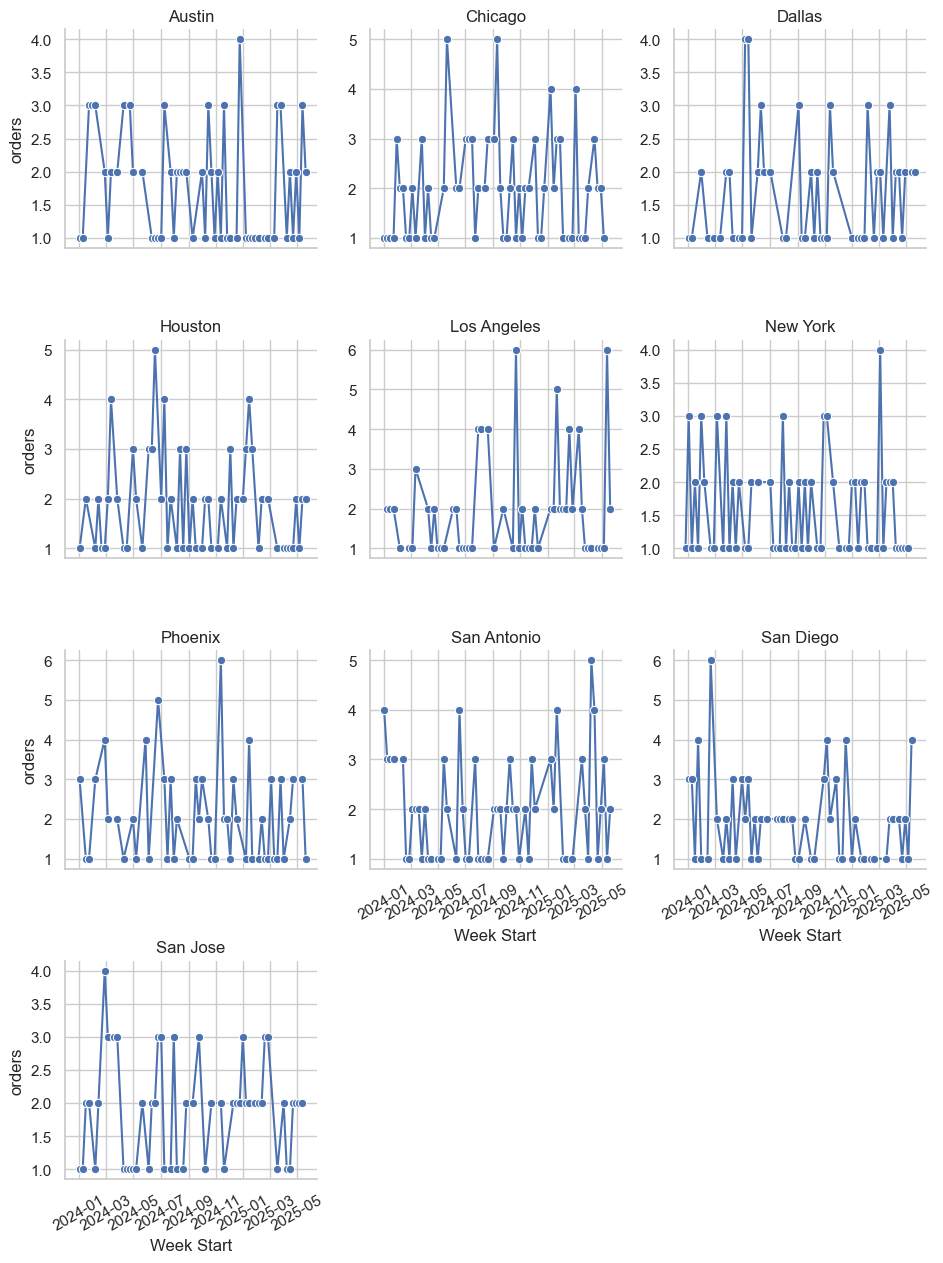

In [13]:
loc_week = (df.groupby(["Location", "Week Start"])
              .agg(orders=("Order ID","count"), revenue=("Revenue","sum"))
              .reset_index())
g = sns.FacetGrid(loc_week, col="Location", col_wrap=3, height=3.2, sharey=False)
g.map_dataframe(sns.lineplot, x="Week Start", y="orders", marker="o")
g.set_titles("{col_name}")
for ax in g.axes.flatten():
    for tick in ax.get_xticklabels(): tick.set_rotation(30)
plt.tight_layout(); plt.show()


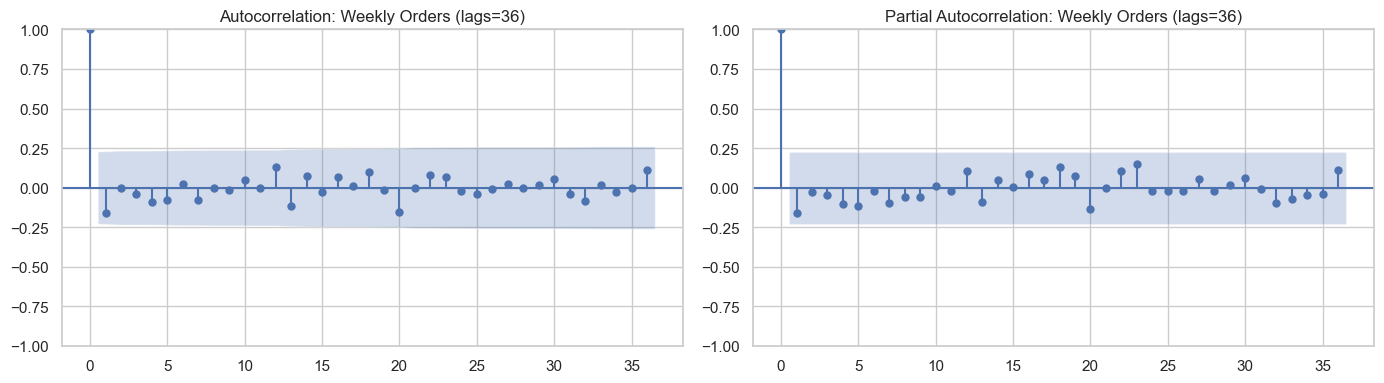

In [14]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Determine a safe lag based on sample size
max_lags = min(40, weekly.shape[0] // 2 - 1)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(weekly["orders"], ax=ax[0], lags=max_lags)
plot_pacf(weekly["orders"], ax=ax[1], lags=max_lags)
ax[0].set_title(f"Autocorrelation: Weekly Orders (lags={max_lags})")
ax[1].set_title(f"Partial Autocorrelation: Weekly Orders (lags={max_lags})")
plt.tight_layout()
plt.show()

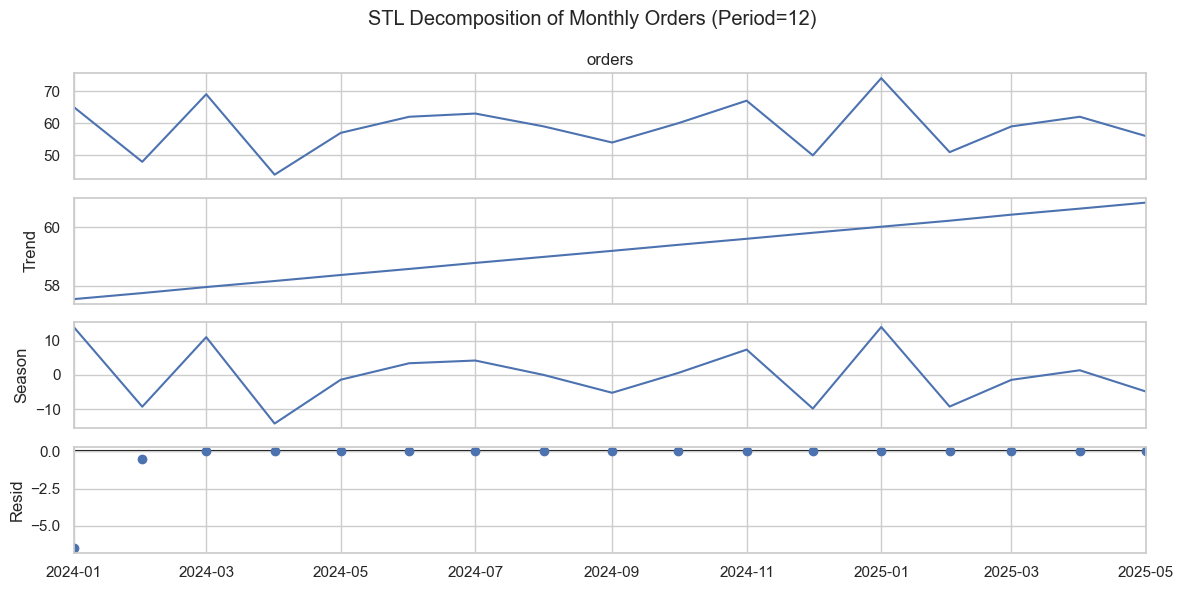

In [15]:
from statsmodels.tsa.seasonal import STL

monthly_orders = month_year.set_index("Month Start")["orders"].asfreq("MS")  # month start freq
stl = STL(monthly_orders, period=12, robust=True)
res = stl.fit()
fig = res.plot()
plt.suptitle("STL Decomposition of Monthly Orders (Period=12)")
plt.tight_layout()
plt.show()



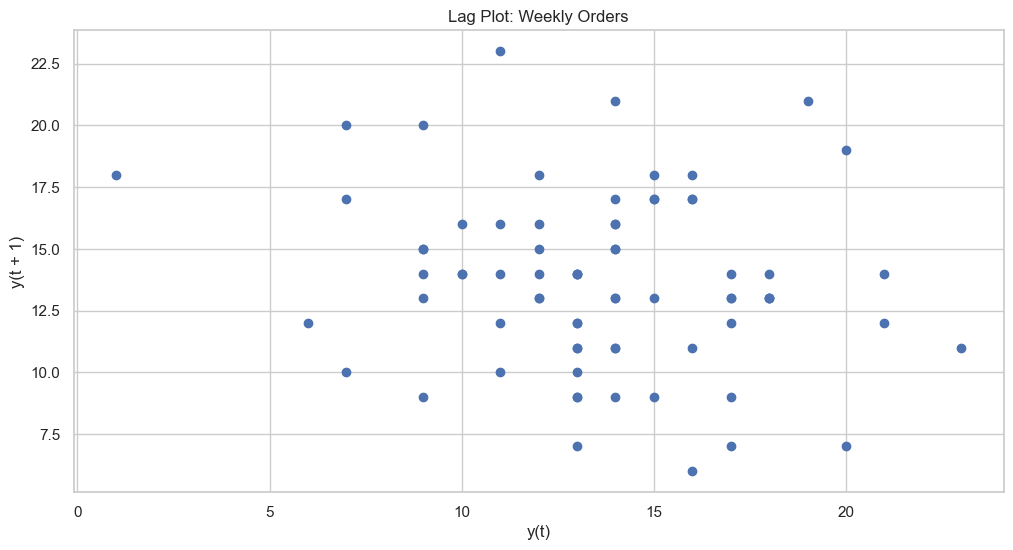

In [16]:
from pandas.plotting import lag_plot

lag_plot(weekly["orders"])
plt.title("Lag Plot: Weekly Orders")
plt.show()


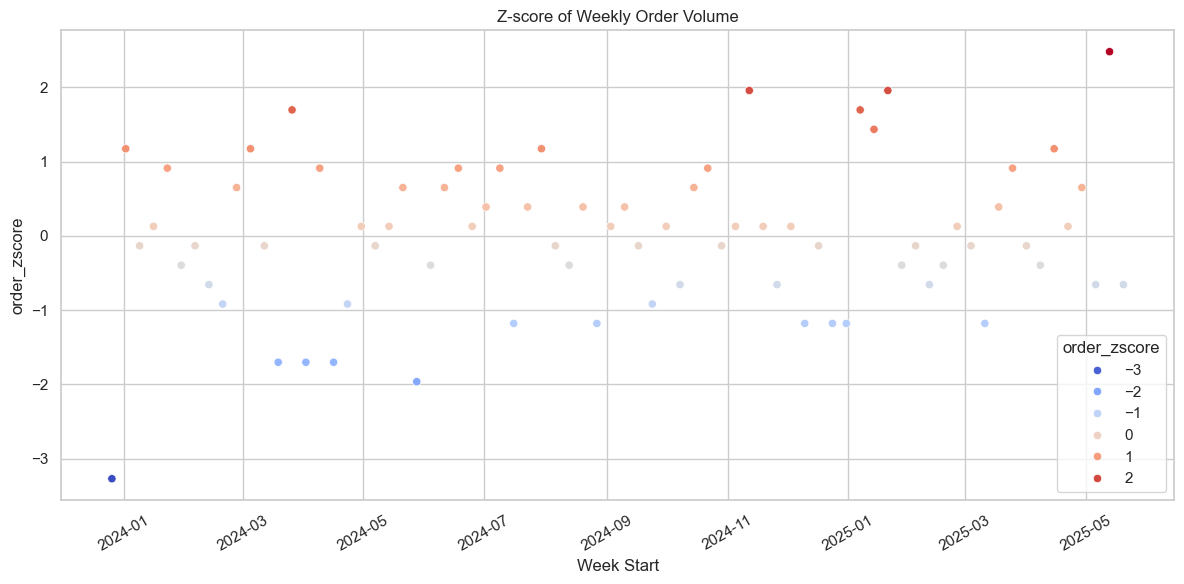

In [17]:
weekly["order_zscore"] = (weekly["orders"] - weekly["orders"].mean()) / weekly["orders"].std()

fig, ax = plt.subplots()
sns.scatterplot(data=weekly, x="Week Start", y="order_zscore", hue="order_zscore", palette="coolwarm", ax=ax)
ax.set_title("Z-score of Weekly Order Volume")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


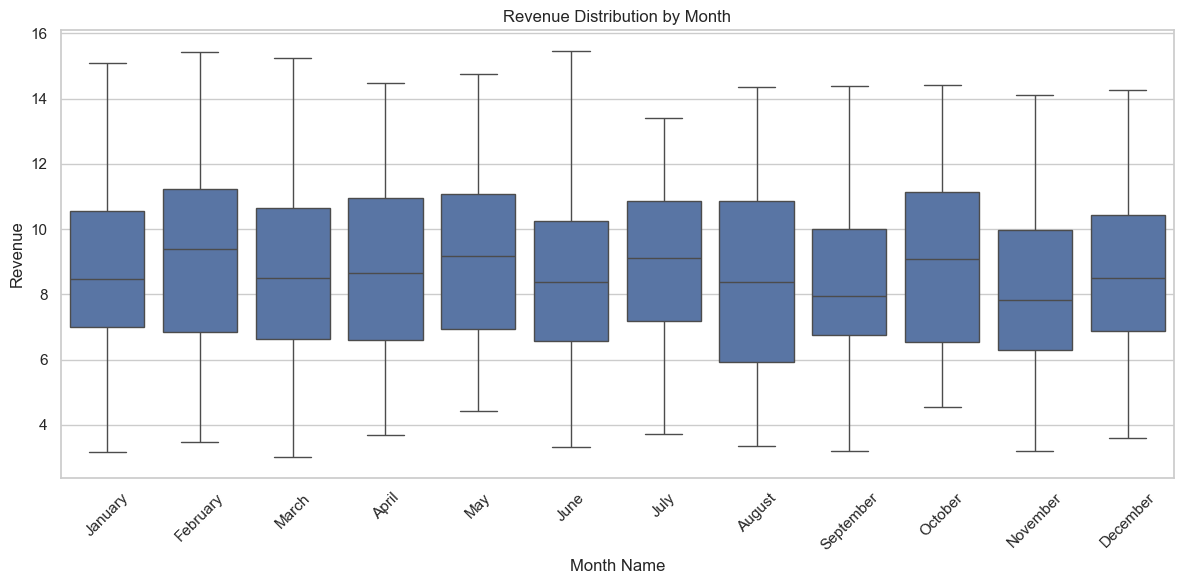

In [18]:
sns.boxplot(data=df, x="Month Name", y="Revenue")
plt.title("Revenue Distribution by Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


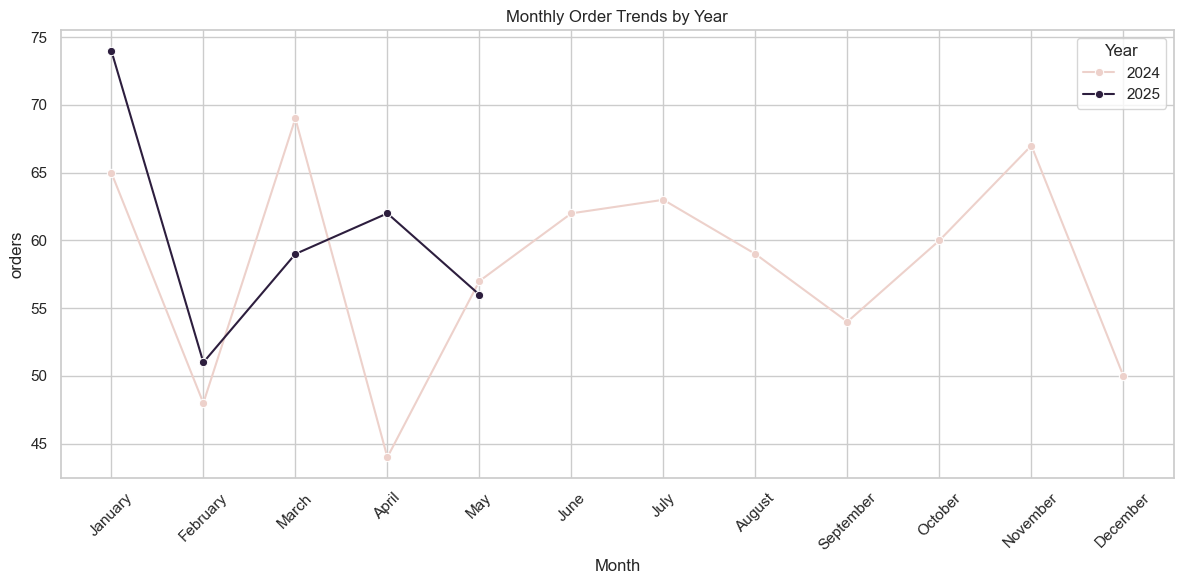

In [19]:
df["Month"] = df["Order Time"].dt.month_name()
df["Year"] = df["Order Time"].dt.year

monthly_trend = (
    df.groupby(["Year", "Month"])
      .agg(orders=("Order ID", "count"))
      .reset_index()
)

monthly_trend["Month"] = pd.Categorical(monthly_trend["Month"], categories=month_order, ordered=True)

sns.lineplot(data=monthly_trend, x="Month", y="orders", hue="Year", marker="o")
plt.title("Monthly Order Trends by Year")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

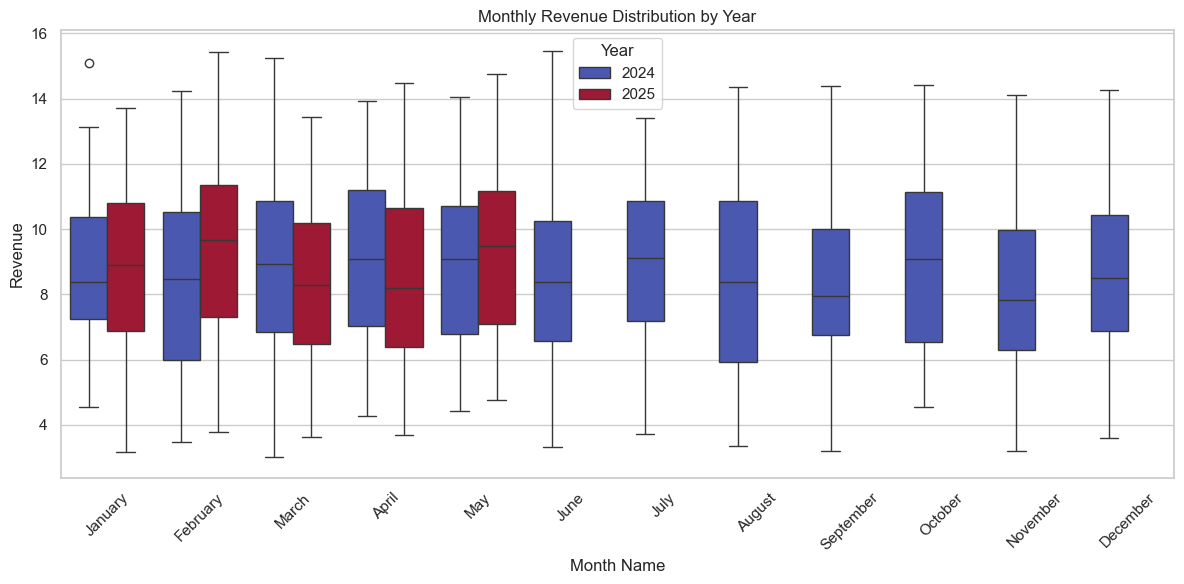

In [20]:
df["Month Name"] = pd.Categorical(df["Month Name"], categories=month_order, ordered=True)

sns.boxplot(data=df, x="Month Name", y="Revenue", hue="Year", palette="coolwarm")
plt.title("Monthly Revenue Distribution by Year")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [21]:
# If needed: pip install plotly
# %pip install plotly


import plotly.express as px



import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- Prep daily data ---
df["Order Time"] = pd.to_datetime(df["Order Time"], dayfirst=True, errors="coerce")
df = df.dropna(subset=["Order Time"]).copy()

df["Order Date"] = df["Order Time"].dt.floor("D")
full_days = pd.date_range(df["Order Date"].min(), df["Order Date"].max(), freq="D")

daily = (
    df.groupby("Order Date")["Order ID"].count()
      .reindex(full_days, fill_value=0)
      .rename("Order_Count")
      .rename_axis("Date")
      .reset_index()
)

daily["Year"] = daily["Date"].dt.year
daily["Month"] = daily["Date"].dt.month
daily["Month Name"] = daily["Date"].dt.month_name()
daily["Day"] = daily["Date"].dt.day
daily["DowIdx"] = daily["Date"].dt.weekday  # Monday=0..Sunday=6
dow_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
daily["Dow"] = daily["DowIdx"].map({i: d for i, d in enumerate(dow_labels)})

def week_of_month(dt: pd.Timestamp) -> int:
    first = dt.replace(day=1)
    return (dt.day + first.weekday() - 1) // 7  # 0-based week index within month

daily["WeekOfMonth"] = daily["Date"].apply(week_of_month)

month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]
daily["Month Name"] = pd.Categorical(daily["Month Name"], categories=month_order, ordered=True)

# --- Build a padded calendar grid for each (Year, Month) ---
pads = []
# Silence the pandas groupby FutureWarning by passing observed=True
for (y, m, mname), sub in daily.groupby(["Year", "Month", "Month Name"], observed=True):
    grid = pd.MultiIndex.from_product([range(6), range(7)], names=["WeekOfMonth", "DowIdx"]).to_frame(index=False)
    grid["Year"] = y
    grid["Month"] = m
    grid["Month Name"] = mname
    grid["Dow"] = grid["DowIdx"].map({i: d for i, d in enumerate(dow_labels)})

    merged = grid.merge(sub[["Date","Order_Count","WeekOfMonth","DowIdx"]],
                        on=["WeekOfMonth","DowIdx"], how="left")
    merged["is_actual_day"] = merged["Date"].notna()
    merged["Order_Count"] = merged["Order_Count"].fillna(0).astype(int)
    merged["DateStr"] = merged["Date"].dt.strftime("%Y-%m-%d").fillna("")
    pads.append(merged)

calendar_df = pd.concat(pads, ignore_index=True)

# --- Helper to create 6x7 matrices for z (orders) and hovertext ---
def month_matrices(frame_df):
    # frame_df filtered to one year-month
    # Rows: WeekOfMonth 0..5 (top to bottom), Columns: DowIdx 0..6 (Mon..Sun)
    pivot = frame_df.pivot(index="WeekOfMonth", columns="DowIdx", values="Order_Count").reindex(index=range(6), columns=range(7), fill_value=0)
    hover = frame_df.pivot(index="WeekOfMonth", columns="DowIdx", values="DateStr").reindex(index=range(6), columns=range(7), fill_value="")
    # We want week 0 at the top visually, but Plotly's Heatmap origin is upper-left by default.
    # We'll reverse y-axis later; keep matrices in natural order here.
    z = pivot.values
    hovertext = hover.values
    return z, hovertext

years = sorted(calendar_df["Year"].unique())
zmax = int(calendar_df["Order_Count"].max())

# --- Create subplots: 4 rows x 3 cols (12 months) ---
fig = make_subplots(
    rows=4, cols=3,
    subplot_titles=month_order,
    horizontal_spacing=0.03, vertical_spacing=0.06
)

# Map month -> subplot position
month_to_rc = {m: ((i // 3) + 1, (i % 3) + 1) for i, m in enumerate(month_order)}

# Add initial year's traces (one heatmap per month)
initial_year = years[0]
init_traces = []
for mname in month_order:
    r, c = month_to_rc[mname]
    sub = calendar_df[(calendar_df["Year"] == initial_year) & (calendar_df["Month Name"] == mname)]
    if sub.empty:
        # empty month placeholder
        z = np.zeros((6,7))
        hovertext = np.full((6,7), "", dtype=object)
    else:
        z, hovertext = month_matrices(sub)

    trace = go.Heatmap(
        z=z,
        x=dow_labels,  # columns
        y=[f"W{i+1}" for i in range(6)],  # rows
        colorscale="YlOrRd",
        zmin=0, zmax=zmax,
        showscale=False,  # we'll add a single shared colorbar later
        hovertemplate="<b>%{customdata}</b><br>Orders: %{z}<extra></extra>",
        customdata=hovertext
    )
    fig.add_trace(trace, row=r, col=c)
    init_traces.append(trace)

# Add a single colorbar on the last subplot
fig.data[-1].update(showscale=True, colorbar=dict(title="Orders", len=0.8))

# Reverse y-axis on each subplot so week 1 at top
for i in range(1, 13):
    axy = f"yaxis{i}"
    fig.layout[axy].update(autorange="reversed", tickmode="array", tickvals=[f"W{i+1}" for i in range(6)], ticktext=[f"W{i+1}" for i in range(6)])
    axx = f"xaxis{i}"
    fig.layout[axx].update(categoryorder="array", categoryarray=dow_labels)

fig.update_layout(
    title=f"Daily Taco Orders — Calendar Heatmap by Month (Year: {initial_year})",
    height=1100,
    margin=dict(t=70, l=40, r=20, b=40)
)

# --- Build animation frames: one frame per year, updating all 12 month heatmaps ---
frames = []
for y in years:
    frame_traces = []
    for mname in month_order:
        sub = calendar_df[(calendar_df["Year"] == y) & (calendar_df["Month Name"] == mname)]
        if sub.empty:
            z = np.zeros((6,7))
            hovertext = np.full((6,7), "", dtype=object)
        else:
            z, hovertext = month_matrices(sub)
        frame_traces.append(go.Heatmap(z=z, customdata=hovertext))
    frames.append(go.Frame(data=frame_traces, name=str(y)))

fig.frames = frames

# --- Play/pause buttons and slider ---
fig.update_layout(
    updatemenus=[
        dict(
            type="buttons",
            showactive=False,
            x=0.02, y=1.12, xanchor="left", yanchor="top",
            buttons=[
                dict(label="▶ Play", method="animate",
                     args=[None, dict(frame=dict(duration=800, redraw=True), transition=dict(duration=300),
                                      fromcurrent=True, mode="immediate")]),
                dict(label="⏸ Pause", method="animate",
                     args=[[None], dict(frame=dict(duration=0, redraw=False), mode="immediate")])
            ]
        )
    ],
    sliders=[dict(
        active=0,
        x=0.15, y=1.08, xanchor="left", yanchor="top",
        len=0.75,
        currentvalue=dict(prefix="Year: ", font=dict(size=14)),
        steps=[dict(label=str(y), method="animate", args=[[str(y)], dict(mode="immediate", frame=dict(duration=0, redraw=True), transition=dict(duration=200))]) for y in years]
    )]
)

fig.show()

# Time Series Forecasting

In [22]:
# %pip install statsmodels scikit-learn tensorflow==2.15.* prophet --quiet

from sklearn.metrics import mean_absolute_error, mean_squared_error
from math import sqrt

# Load and parse
df_raw = pd.read_csv("Taco_Sales.csv")
df_raw["Order Time"] = pd.to_datetime(df_raw["Order Time"], dayfirst=True, errors="coerce")
df = df_raw.dropna(subset=["Order Time"]).copy()

# Aggregate to weekly orders (Monday-start)
df["Week Start"] = df["Order Time"].dt.to_period("W-MON").apply(lambda p: p.start_time)

# Count orders per week using .size() for robustness
weekly_orders = (
    df.groupby("Week Start")
      .size()
      .rename("y")
      .to_frame()
)

# Create a complete weekly index
full_index = pd.date_range(start=weekly_orders.index.min(), end=weekly_orders.index.max(), freq="W-MON")

# Reindex and interpolate missing weeks
weekly_orders = weekly_orders.reindex(full_index)
weekly_orders.index.name = "week"

# Interpolate missing values
weekly_orders["y"] = weekly_orders["y"].interpolate(method="linear")

# Replace any remaining zeros with small random values (optional)
weekly_orders["y"] = weekly_orders["y"].apply(lambda x: x if x > 0 else np.random.randint(5, 15))

# Train/test split (last 12 weeks for test)
H = 12
train = weekly_orders.iloc[:-H].copy()
test = weekly_orders.iloc[-H:].copy()

print(f"Train: {train.index.min().date()} → {train.index.max().date()}  ({len(train)} weeks)")
print(f"Test:  {test.index.min().date()} → {test.index.max().date()}  ({len(test)} weeks)")

# Metrics helper
def metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = sqrt(mean_squared_error(y_true, y_pred))
    mape = (np.abs((y_true - y_pred) / np.maximum(y_true, 1e-8))).mean() * 100
    return {"MAE": mae, "RMSE": rmse, "MAPE%": mape}

# Plot helper
def plot_forecast(actual, preds_dict, title="Forecast vs Actual"):
    plt.figure(figsize=(12,6))
    plt.plot(actual.index, actual.values, label="Actual", color="black", linewidth=2)
    for name, series in preds_dict.items():
        plt.plot(series.index, series.values, label=name)
    plt.title(title); plt.ylabel("Weekly orders"); plt.xlabel("Week")
    plt.legend(); plt.tight_layout(); plt.show()

Train: 2024-01-01 → 2025-02-24  (61 weeks)
Test:  2025-03-03 → 2025-05-19  (12 weeks)


In [23]:
print("Train summary:")
print(train.describe())
print("\nTest summary:")
print(test.describe())

print("\nAny NaNs in train?", train.isna().sum())
print("Any NaNs in test?", test.isna().sum())


Train summary:
               y
count  61.000000
mean    9.524590
std     2.772523
min     5.000000
25%     7.000000
50%     9.000000
75%    11.000000
max    14.000000

Test summary:
               y
count  12.000000
mean    9.666667
std     2.774341
min     6.000000
25%     7.500000
50%    10.500000
75%    12.000000
max    14.000000

Any NaNs in train? y    0
dtype: int64
Any NaNs in test? y    0
dtype: int64


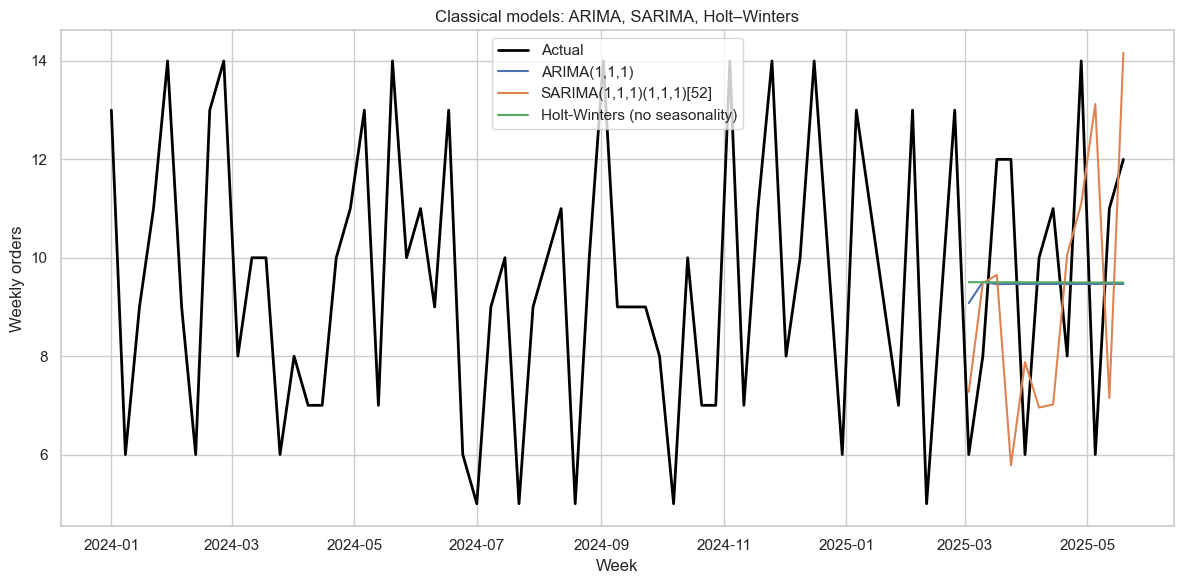

,MAE,RMSE,MAPE%
"ARIMA(1,1,1)",2.393803,2.626094,27.752557
Holt-Winters (no seasonality),2.417495,2.662218,28.292609
"SARIMA(1,1,1)(1,1,1)[52]",3.195310,3.648015,35.627277


In [24]:
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

y_train = train["y"]
y_test = test["y"]

preds = {}
scores = {}

# ARIMA (non-seasonal)
arima_model = SARIMAX(y_train, order=(1,1,1), enforce_stationarity=False, enforce_invertibility=False)
arima_fit = arima_model.fit(disp=False)
arima_fc = arima_fit.get_forecast(steps=len(test)).predicted_mean
arima_fc.index = test.index

preds["ARIMA(1,1,1)"] = arima_fc
scores["ARIMA(1,1,1)"] = metrics(y_test.values, arima_fc.values)

# SARIMA with weekly seasonality m=52
sarima_model = SARIMAX(y_train, order=(1,1,1), seasonal_order=(1,1,1,52),
                       enforce_stationarity=False, enforce_invertibility=False)
sarima_fit = sarima_model.fit(disp=False)
sarima_fc = sarima_fit.get_forecast(steps=len(test)).predicted_mean
sarima_fc.index = test.index

preds["SARIMA(1,1,1)(1,1,1)[52]"] = sarima_fc
scores["SARIMA(1,1,1)(1,1,1)[52]"] = metrics(y_test.values, sarima_fc.values)

seasonal_periods = 52
min_required = 2 * seasonal_periods  # ideally 104

if len(y_train.dropna()) >= min_required:
    hw_model = ExponentialSmoothing(
        y_train,
        trend="add",
        seasonal="add",
        seasonal_periods=seasonal_periods,
        initialization_method="estimated"
    )
    hw_fit = hw_model.fit(optimized=True, use_brute=True)
    hw_fc = hw_fit.forecast(len(test))
    hw_fc.index = test.index

    preds["Holt-Winters"] = hw_fc
    scores["Holt-Winters"] = metrics(y_test.values, hw_fc.values)

elif len(y_train.dropna()) >= seasonal_periods:
    # fallback to non-seasonal Holt-Winters
    hw_model = ExponentialSmoothing(
        y_train,
        trend="add",
        seasonal=None,
        initialization_method="estimated"
    )
    hw_fit = hw_model.fit(optimized=True, use_brute=True)
    hw_fc = hw_fit.forecast(len(test))
    hw_fc.index = test.index

    preds["Holt-Winters (no seasonality)"] = hw_fc
    scores["Holt-Winters (no seasonality)"] = metrics(y_test.values, hw_fc.values)

else:
    print("Skipping Holt-Winters: insufficient data for seasonal modeling")

# Visualize
plot_forecast(
    pd.concat([y_train, y_test]),
    {k: pd.concat([pd.Series(index=y_train.index, dtype=float), v]) for k, v in preds.items()},
    title="Classical models: ARIMA, SARIMA, Holt–Winters"
)

# Show scores
pd.DataFrame(scores).T.sort_values("RMSE")

In [25]:
def create_lag_features(df, lags=[1, 2, 3, 4, 5, 6, 7]):
    df_lagged = df.copy()
    for lag in lags:
        df_lagged[f"lag_{lag}"] = df_lagged["y"].shift(lag)
    return df_lagged.dropna()
weekly_lagged = create_lag_features(weekly_orders)

In [26]:
H = 12
train_lagged = weekly_lagged.iloc[:-H].copy()
test_lagged = weekly_lagged.iloc[-H:].copy()

X_train = train_lagged.drop(columns=["y"])
y_train = train_lagged["y"]
X_test = test_lagged.drop(columns=["y"])
y_test = test_lagged["y"]

In [27]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [28]:
rf_pred = rf.predict(X_test)
gb_pred = gb.predict(X_test)

rf_metrics = metrics(y_test.values, rf_pred)
gb_metrics = metrics(y_test.values, gb_pred)

print("Random Forest:", rf_metrics)
print("Gradient Boosting:", gb_metrics)

Random Forest: {'MAE': 1.9666666666666668, 'RMSE': 2.3665199485038504, 'MAPE%': 22.18545274170274}
Gradient Boosting: {'MAE': 2.0119518439477204, 'RMSE': 2.4606005064409735, 'MAPE%': 21.565382610325}


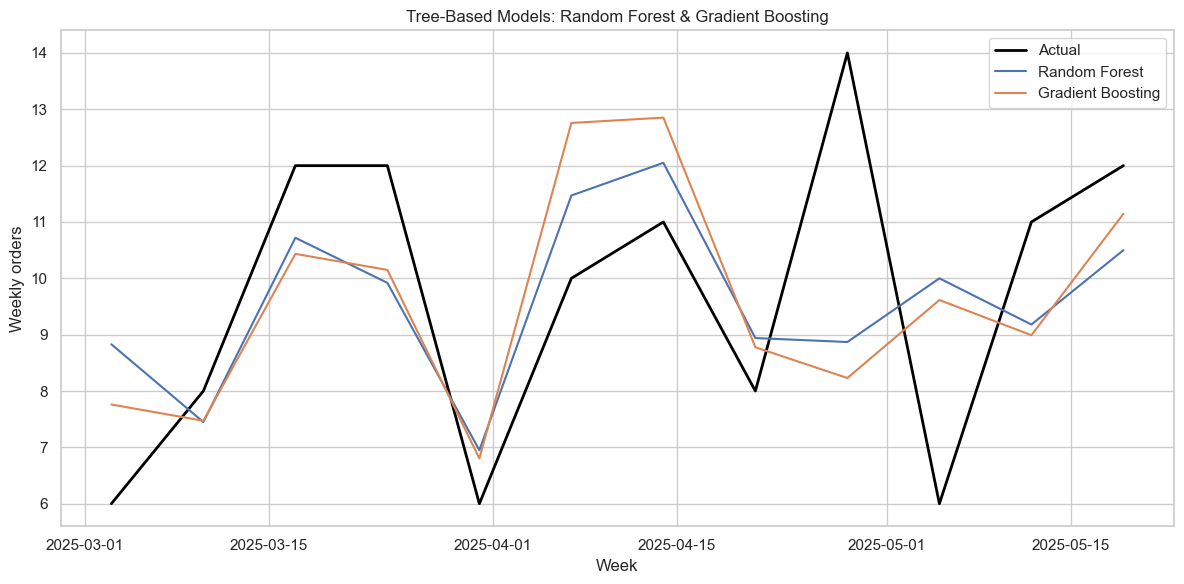

In [29]:
plot_forecast(
    actual=y_test,
    preds_dict={
        "Random Forest": pd.Series(rf_pred, index=y_test.index),
        "Gradient Boosting": pd.Series(gb_pred, index=y_test.index)
    },
    title="Tree-Based Models: Random Forest & Gradient Boosting"
)

In [30]:
def create_lag_and_rolling_features(df, lags=[1, 2, 3, 4, 5, 6, 7], windows=[3, 4, 7]):
    df_feat = df.copy()
    
    # Lag features
    for lag in lags:
        df_feat[f"lag_{lag}"] = df_feat["y"].shift(lag)
    
    # Rolling averages
    for window in windows:
        df_feat[f"roll_mean_{window}"] = df_feat["y"].shift(1).rolling(window=window).mean()
    
    return df_feat.dropna()
weekly_features = create_lag_and_rolling_features(weekly_orders)

In [31]:
H = 12
train_feat = weekly_features.iloc[:-H].copy()
test_feat = weekly_features.iloc[-H:].copy()

X_train = train_feat.drop(columns=["y"])
y_train = train_feat["y"]
X_test = test_feat.drop(columns=["y"])
y_test = test_feat["y"]

In [32]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

Random Forest: {'MAE': 2.0025, 'RMSE': 2.4644353646761905, 'MAPE%': 22.61856060606061}
Gradient Boosting: {'MAE': 2.1986575063406004, 'RMSE': 2.7082368064212314, 'MAPE%': 25.152042809076946}


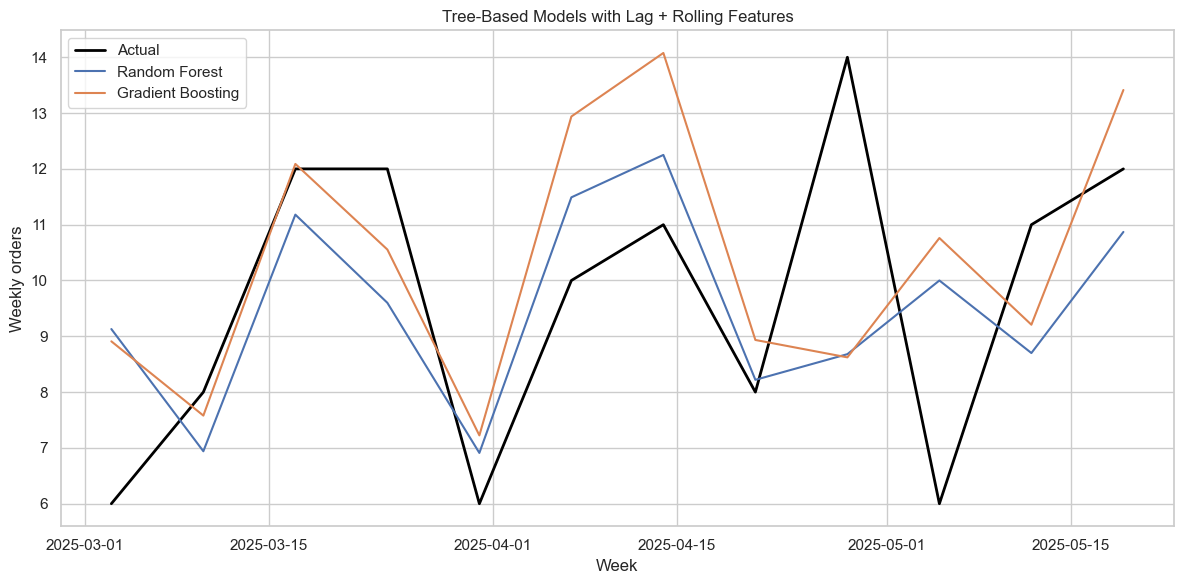

In [33]:
rf_pred = rf.predict(X_test)
gb_pred = gb.predict(X_test)

print("Random Forest:", metrics(y_test.values, rf_pred))
print("Gradient Boosting:", metrics(y_test.values, gb_pred))

plot_forecast(
    actual=y_test,
    preds_dict={
        "Random Forest": pd.Series(rf_pred, index=y_test.index),
        "Gradient Boosting": pd.Series(gb_pred, index=y_test.index)
    },
    title="Tree-Based Models with Lag + Rolling Features"
)

In [34]:
def create_lstm_sequences(series, window=8):
    X, y = [], []
    for i in range(len(series) - window):
        X.append(series[i:i+window])
        y.append(series[i+window])
    return np.array(X), np.array(y)

In [35]:
series = weekly_orders["y"].values
window_size = 8

X_all, y_all = create_lstm_sequences(series, window=window_size)

In [36]:
H = 12
X_train, X_test = X_all[:-H], X_all[-H:]
y_train, y_test = y_all[:-H], y_all[-H:]

In [37]:
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [38]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(64, activation="relu", input_shape=(window_size, 1)),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")
model.fit(X_train, y_train, epochs=100, verbose=0)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
LSTM: {'MAE': 1.7924956878026326, 'RMSE': 2.11708339277662, 'MAPE%': 19.775438971849745}


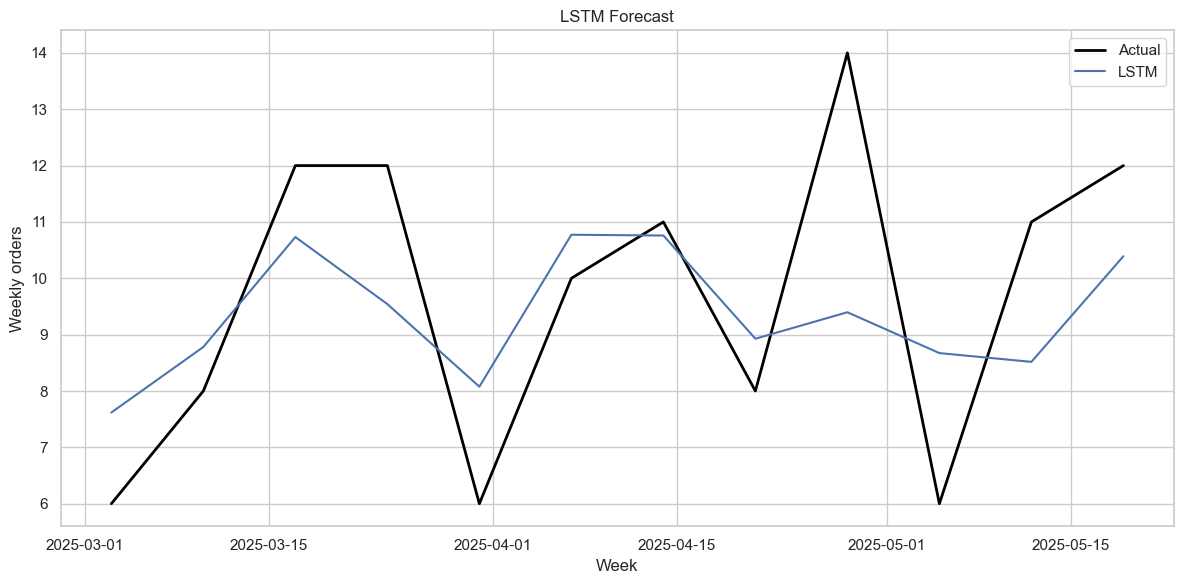

In [39]:
lstm_pred = model.predict(X_test).flatten()

print("LSTM:", metrics(y_test, lstm_pred))

plot_forecast(
    actual=pd.Series(y_test, index=weekly_orders.index[-H:]),
    preds_dict={"LSTM": pd.Series(lstm_pred, index=weekly_orders.index[-H:])},
    title="LSTM Forecast"
)

lstm_model = model

In [40]:
df_prophet = weekly_orders.reset_index().rename(columns={"week": "ds", "y": "y"})

In [41]:
H = 12
train_prophet = df_prophet.iloc[:-H].copy()
test_prophet = df_prophet.iloc[-H:].copy()

In [42]:
!pip install Prophet

Defaulting to user installation because normal site-packages is not writeable


In [43]:
from prophet import Prophet

model = Prophet(weekly_seasonality=True, daily_seasonality=False)
model.fit(train_prophet)

13:54:16 - cmdstanpy - INFO - Chain [1] start processing
13:54:16 - cmdstanpy - INFO - Chain [1] done processing


In [44]:
future = model.make_future_dataframe(periods=H, freq="W-MON")
forecast = model.predict(future)

In [45]:
fc = forecast.set_index("ds")["yhat"].loc[test_prophet["ds"]]

prophet_metrics = metrics(test_prophet["y"].values, fc.values)
print("Prophet:", prophet_metrics)

Prophet: {'MAE': 2.418486345365205, 'RMSE': 2.6625970919059467, 'MAPE%': 28.28532015203192}


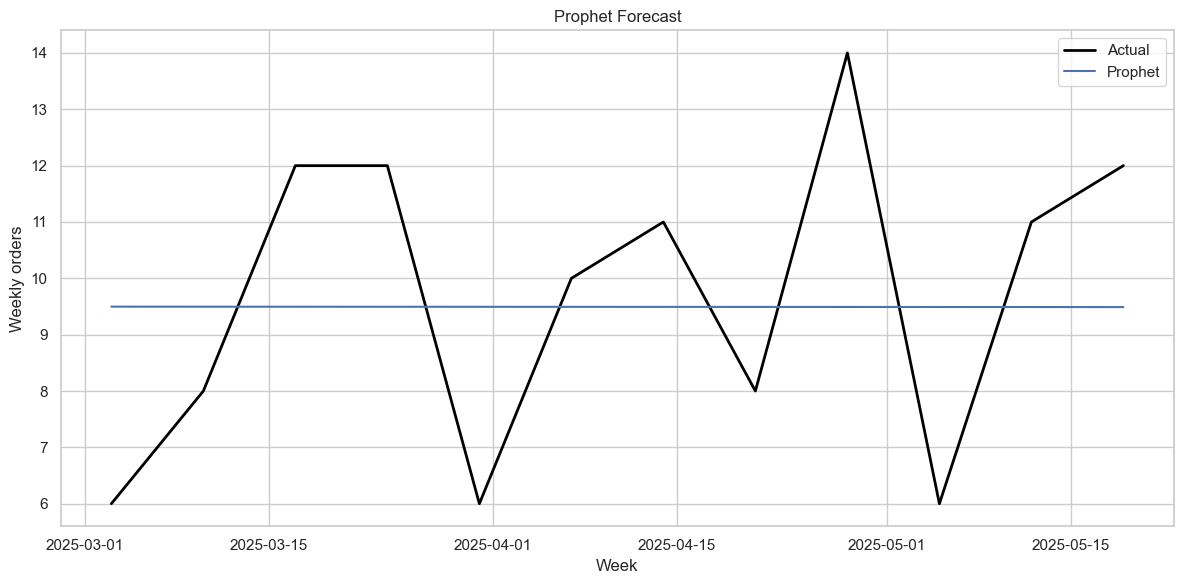

In [46]:
plot_forecast(
    actual=test_prophet.set_index("ds")["y"],
    preds_dict={"Prophet": fc},
    title="Prophet Forecast"
)

In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def smape(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    diff = np.abs(y_true - y_pred)
    return np.mean(diff / denominator) * 100

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred, squared=False),
        "MAPE": mape(y_true, y_pred),
        "SMAPE": smape(y_true, y_pred)
    }


In [48]:
y_true = test_prophet["y"].values

In [49]:
H = len(test_prophet)  

In [50]:
arima_results = arima_model.fit()
fc_arima = arima_results.get_forecast(steps=H).predicted_mean
fc_arima = pd.Series(fc_arima, index=test_prophet["ds"])

sarima_results = sarima_model.fit()
fc_sarima = sarima_results.get_forecast(steps=H).predicted_mean
fc_sarima = pd.Series(fc_sarima, index=test_prophet["ds"])

hw_results = hw_model.fit()
fc_hw = hw_results.forecast(steps=H)
fc_hw = pd.Series(fc_hw, index=test_prophet["ds"])

In [51]:
results = {}

# Classical models
results["ARIMA"] = metrics(test_prophet["y"].values, fc_arima.values)
results["SARIMA"] = metrics(test_prophet["y"].values, fc_sarima.values)
results["Holt-Winters"] = metrics(test_prophet["y"].values, fc_hw.values)

# Prophet
fc_prophet = forecast.set_index("ds")["yhat"].loc[test_prophet["ds"]]
results["Prophet"] = metrics(test_prophet["y"].values, fc_prophet.values)

# ML models
#results["ML Model"] = metrics(y_test, fc_ml)
results["LSTM"] = metrics(y_test, lstm_model.predict(X_test).flatten())

X_test_flat = X_test.reshape(X_test.shape[0], -1)
rf.fit(X_train.reshape(X_train.shape[0], -1), y_train)
gb.fit(X_train.reshape(X_train.shape[0], -1), y_train)

results["Random Forest"] = metrics(y_test, rf.predict(X_test_flat))
results["Gradient Boosting"] = metrics(y_test, gb.predict(X_test_flat))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


In [52]:
print(f"The accuracy of the ARIMA model: {results["ARIMA"]}")
print(f"The accuracy of the SARIMA model: {results["SARIMA"]}")
print(f"The accuracy of the Holt-Winters model: {results["Holt-Winters"]}")
print(f"The accuracy of the Prophet model: {results["Prophet"]}")
print(f"The accuracy of the LSTM model: {results["LSTM"]}")
print(f"The accuracy of the Random Forest model: {results["Random Forest"]}")
print(f"The accuracy of the Gradient Boosting model: {results["Gradient Boosting"]}")

The accuracy of the ARIMA model: {'MAE': 2.3938025418467705, 'RMSE': 2.6260936324651514, 'MAPE': 27.752557129057603, 'SMAPE': 25.78830497629056}
The accuracy of the SARIMA model: {'MAE': 3.1953103821775186, 'RMSE': 3.6480149772398356, 'MAPE': 35.62727699154311, 'SMAPE': 34.54607638457196}
The accuracy of the Holt-Winters model: {'MAE': 2.417495385539516, 'RMSE': 2.662217667169195, 'MAPE': 28.29260871648499, 'SMAPE': 26.027853524266853}
The accuracy of the Prophet model: {'MAE': 2.418486345365205, 'RMSE': 2.6625970919059467, 'MAPE': 28.28532015203192, 'SMAPE': 26.038703619045677}
The accuracy of the LSTM model: {'MAE': 1.7924956878026326, 'RMSE': 2.11708339277662, 'MAPE': 19.775438971849745, 'SMAPE': 19.396267976860027}
The accuracy of the Random Forest model: {'MAE': 2.095833333333333, 'RMSE': 2.581015626970644, 'MAPE': 23.831006493506493, 'SMAPE': 22.050299183014744}
The accuracy of the Gradient Boosting model: {'MAE': 2.14372373904818, 'RMSE': 2.7406715019930648, 'MAPE': 23.989501119

In [53]:
def pick_best_model(results):
    # Convert results dict to DataFrame
    df = pd.DataFrame(results).T

    # Rank each metric (lower is better)
    ranks = df.rank(method="min")

    # Compute average rank
    avg_rank = ranks.mean(axis=1)

    # Find model with lowest average rank
    best_model = avg_rank.idxmin()

    return best_model, df.loc[best_model].to_dict()
best_model, best_metrics = pick_best_model(results)
print(f"Best model: {best_model}")
print("Metrics:", best_metrics)

Best model: LSTM
Metrics: {'MAE': 1.7924956878026326, 'RMSE': 2.11708339277662, 'MAPE': 19.775438971849745, 'SMAPE': 19.396267976860027}


# Price Optimazation Prediction

In [54]:
# reloading data so these models are not influenced by transformations used by last ML models
df2 = pd.read_csv("Taco_Sales.csv")

# Create revenue column
df2["Revenue"] = df["Price ($)"] + df["Tip ($)"]

# Convert time columns
df2["Order Time"] = pd.to_datetime(df["Order Time"])
df2["DayOfWeek"] = df["Order Time"].dt.dayofweek  # 0=Monday, 6=Sunday

# Encode categorical features
df2["Weekend Order"] = df["Weekend Order"].astype(int)
df2["Taco Size"] = df["Taco Size"].map({"Regular": 0, "Large": 1})
df2["Taco Type"] = df["Taco Type"].astype("category").cat.codes
df2["Location"] = df["Location"].astype("category").cat.codes


In [55]:

import xgboost as xgb
from sklearn.model_selection import train_test_split

# Features and target
features = ["Price ($)", "DayOfWeek", "Weekend Order", "Taco Size", "Taco Type", "Location", "Toppings Count", "Distance (km)", "Delivery Duration (min)"]
X = df2[features]
y = df2["Revenue"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest
rf2 = RandomForestRegressor()
rf2.fit(X_train, y_train)

# Train XGBoost
xgb_model = xgb.XGBRegressor()
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [56]:

def simulate_optimal_price(model, base_features, price_range, feature_order):
    simulated = pd.DataFrame([base_features] * len(price_range))
    simulated["Price ($)"] = price_range
    simulated = simulated[feature_order]  # Ensure correct column order
    predicted_revenue = model.predict(simulated)
    optimal_price = price_range[np.argmax(predicted_revenue)]
    return optimal_price, predicted_revenue

feature_order = ["Price ($)", "DayOfWeek", "Weekend Order", "Taco Size", "Taco Type", "Location", "Toppings Count", "Distance (km)", "Delivery Duration (min)"]
price_range = np.linspace(3, 12, 100)  # Simulate prices from $3 to $12

base_features = {
    "DayOfWeek": 4,  # Friday
    "Weekend Order": 1,
    "Taco Size": 1,
    "Taco Type": 2,
    "Location": 5,
    "Toppings Count": 3,
    "Distance (km)": 5.0,
    "Delivery Duration (min)": 40
}

optimal_price_rf, revenue_rf = simulate_optimal_price(rf2, base_features, price_range, feature_order)
optimal_price_xgb, revenue_xgb = simulate_optimal_price(xgb_model, base_features, price_range, feature_order)

print(f"Optimal price (RF): ${optimal_price_rf:.2f}")
print(f"Optimal price (XGB): ${optimal_price_xgb:.2f}")

Optimal price (RF): $10.18
Optimal price (XGB): $10.82


In [57]:
y_pred_rf = rf2.predict(X_test)
y_pred_xgb = xgb_model.predict(X_test)


def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {"MAE": mae, "RMSE": rmse}

rf_metrics = evaluate_model(y_test, y_pred_rf)
xgb_metrics = evaluate_model(y_test, y_pred_xgb)

print("Random Forest Performance:")
print(rf_metrics)

print("\nXGBoost Performance:")
print(xgb_metrics)

Random Forest Performance:
{'MAE': 0.9129025000000002, 'RMSE': 1.1508522207260152}

XGBoost Performance:
{'MAE': 0.9953078831672668, 'RMSE': 1.2991216096333658}


In [58]:

comparison_df = pd.DataFrame({
    "Random Forest": rf_metrics,
    "XGBoost": xgb_metrics
})
print(comparison_df)

      Random Forest   XGBoost
MAE        0.912903  0.995308
RMSE       1.150852  1.299122


In [60]:
def smape(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    return np.mean(np.abs(y_true - y_pred) / denominator) * 100

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def select_best_model(models, X_test, y_test):
    """
    Compare models using MAE, RMSE, MAPE, SMAPE and return the most accurate one.
    
    Parameters:
        models (dict): Dictionary of model name → model object
        X_test (DataFrame): Test features
        y_test (Series or array): True target values
    
    Returns:
        best_model_name (str): Name of the best model
        metrics_df (DataFrame): MAE, RMSE, MAPE, SMAPE for each model
    """
    metrics = {}
    
    for name, model in models.items():
        y_pred = model.predict(X_test)
        metrics[name] = {
            "MAE": mean_absolute_error(y_test, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
            "MAPE": mape(y_test, y_pred),
            "SMAPE": smape(y_test, y_pred)
        }
    
    # Convert to DataFrame
    metrics_df = pd.DataFrame(metrics).T
    
    # Rank each metric (lower is better)
    ranks = metrics_df.rank(method="min")
    avg_rank = ranks.mean(axis=1)
    
    # Select best model
    best_model_name = avg_rank.idxmin()
    
    return best_model_name, metrics_df


models = {
    "Random Forest": rf2,
    "XGBoost": xgb_model
}

best_model, metrics_table = select_best_model(models, X_test, y_test)
print("Best model:", best_model)
print(metrics_table)


Best model: Random Forest
                    MAE      RMSE       MAPE      SMAPE
Random Forest  0.912903  1.150852  11.307422  10.956915
XGBoost        0.995308  1.299122  12.072019  11.769523


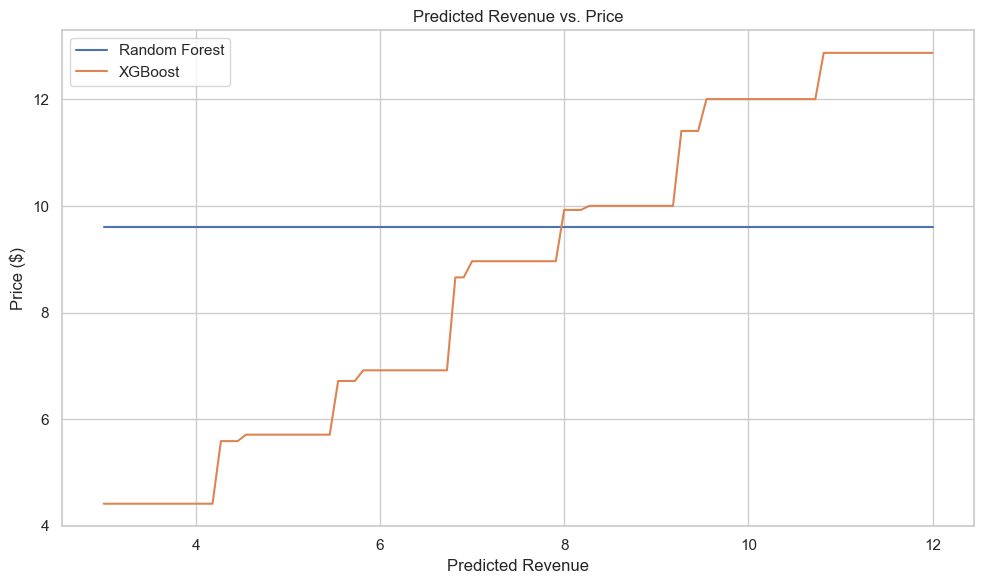

In [63]:

def plot_revenue_curve(models, base_features, price_range, feature_sets):
    """
    Plot predicted revenue across a range of prices for multiple models.
    
    Parameters:
        models (dict): Dictionary of model name → model object
        base_features (dict): Fixed feature values (excluding price)
        price_range (array): Array of prices to simulate
        feature_sets (dict): Dictionary of model name → list of feature names
    """
    plt.figure(figsize=(10, 6))
    
    for name, model in models.items():
        features = feature_sets[name]
        simulated = pd.DataFrame([base_features] * len(price_range))
        
        if "Price ($)" in features:
            simulated["Price ($)"] = price_range
        
        simulated = simulated[features]
        predicted_revenue = model.predict(simulated)
        plt.plot(price_range, predicted_revenue, label=name)
    
    plt.title("Predicted Revenue vs. Price")
    plt.xlabel("Predicted Revenue")
    plt.ylabel("Price ($)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

price_range = np.linspace(3, 12, 100)

base_features = {
    "DayOfWeek": 4,
    "Weekend Order": 1,
    "Taco Size": 1,
    "Taco Type": 2,
    "Location": 5,
    "Toppings Count": 3,
    "Distance (km)": 5.0,
    "Delivery Duration (min)": 40
}

models = {
    "Random Forest": rf,
    "XGBoost": xgb_model
}

feature_sets = {
    "Random Forest": ["DayOfWeek", "Weekend Order", "Taco Size", "Taco Type", "Location", "Toppings Count", "Distance (km)", "Delivery Duration (min)"],
    "XGBoost": ["Price ($)", "DayOfWeek", "Weekend Order", "Taco Size", "Taco Type", "Location", "Toppings Count", "Distance (km)", "Delivery Duration (min)"]
}

plot_revenue_curve(models, base_features, price_range, feature_sets)

# Exporting to PowerBI

In [65]:
!pip install powerbiclient

Defaulting to user installation because normal site-packages is not writeable
